# NumPy Project 3 — Channel Simulation and Signal Propagation

## What this project does
Simulates how a wireless signal gets distorted as it travels
through a real channel — multipath reflections, fading, and Doppler shift.

## Key concepts
- Multipath propagation: signal arrives via multiple paths
- Fading: signal amplitude fluctuates due to path interference
- Doppler shift: frequency shift due to relative motion
- AWGN: additive white Gaussian noise

## Why this matters
Every wireless system — 5G, WiFi, satellite — must deal with
these channel effects. Understanding them is the foundation
of channel estimation and equalisation.

In [31]:
import numpy as np
from scipy import signal as sp
import matplotlib.pyplot as plt

Transmit signal: 1000 Hz sine wave
Samples: 10000, Duration: 1.0 s, fs: 10000 Hz


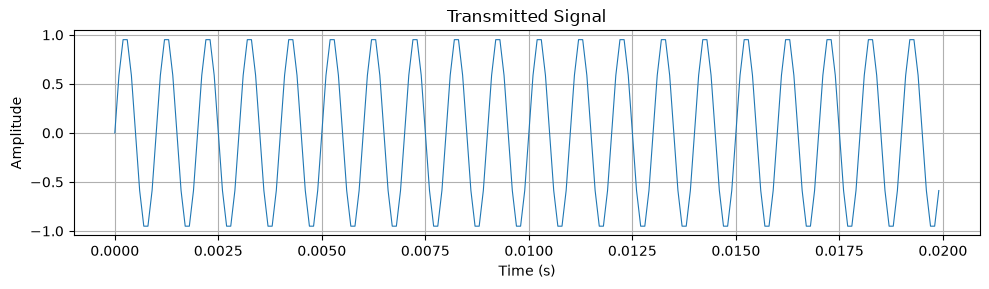

In [32]:
fs = 10000        # sampling frequency in Hz
T = 1.0           # duration in seconds
t = np.arange(0, T, 1/fs)
# time axis: 10000 samples over 1 second

f_carrier = 1000   # carrier frequency in Hz

tx = np.sin(2 * np.pi * f_carrier * t)
# in real systems this would be GHz — we use 1000 Hz for simulation

print(f"Transmit signal: {f_carrier} Hz sine wave")
print(f"Samples: {len(tx)}, Duration: {T} s, fs: {fs} Hz")

plt.figure(figsize=(10, 3))
plt.plot(t[:200], tx[:200], linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Transmitted Signal")
plt.grid(True)
plt.tight_layout()
plt.show()


Channel Impulse Response:
  Path delay=0 samples (0.00 ms), amplitude=1
  Path delay=15 samples (1.50 ms), amplitude=0.7
  Path delay=35 samples (3.50 ms), amplitude=0.4
  Path delay=60 samples (6.00 ms), amplitude=0.2


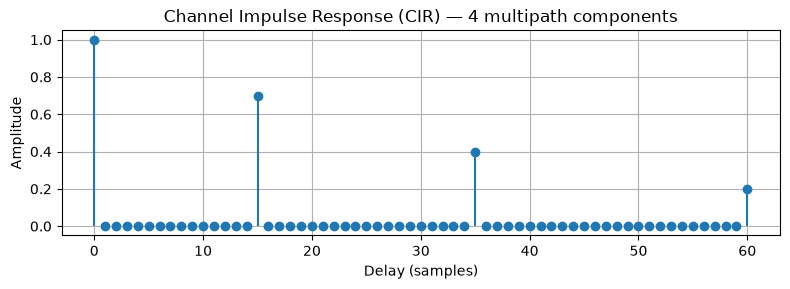

In [33]:
# --- multipath: signal arrives via multiple reflected paths ---
# each path has a different delay and amplitude loss

# define multipath components
path_delays = [0, 15, 35, 60]
# delay in samples for each path
# path 0: direct line of sight, no delay
# path 1: reflected off a wall — 15 samples later
# path 2: reflected off a building — 35 samples later
# path 3: reflected off a distant object — 60 samples later

path_amplitudes = [1, 0.7, 0.4, 0.2] 
# amplitude of each path
# direct path is strongest (1.0)
# each reflection loses energy — further path = weaker signal]

# build the channel impulse response (CIR)
max_delay = np.max(path_delays)
cir = np.zeros(max_delay + 1)
# np.zeros(): initialise impulse response with zeros
# length = longest delay + 1

for delay, amplitude in zip(path_delays, path_amplitudes):
    cir[delay] = amplitude
# place each path amplitude at its delay position
# zip(): pairs each delay with its amplitude    

print("Channel Impulse Response:")
for d, a in zip(path_delays, path_amplitudes):
    print(f"  Path delay={d} samples ({d/fs*1000:.2f} ms), amplitude={a}")

# plot the channel impulse response
plt.figure(figsize=(8, 3))
plt.stem(np.arange(len(cir)), cir, linefmt='C0-', markerfmt='C0o', basefmt=' ')
# plt.stem(): vertical lines — perfect for impulse response
plt.xlabel("Delay (samples)")
plt.ylabel("Amplitude")
plt.title("Channel Impulse Response (CIR) — 4 multipath components")
plt.grid(True)
plt.tight_layout()
plt.show()    
                   

Delay spread: 6.00 ms


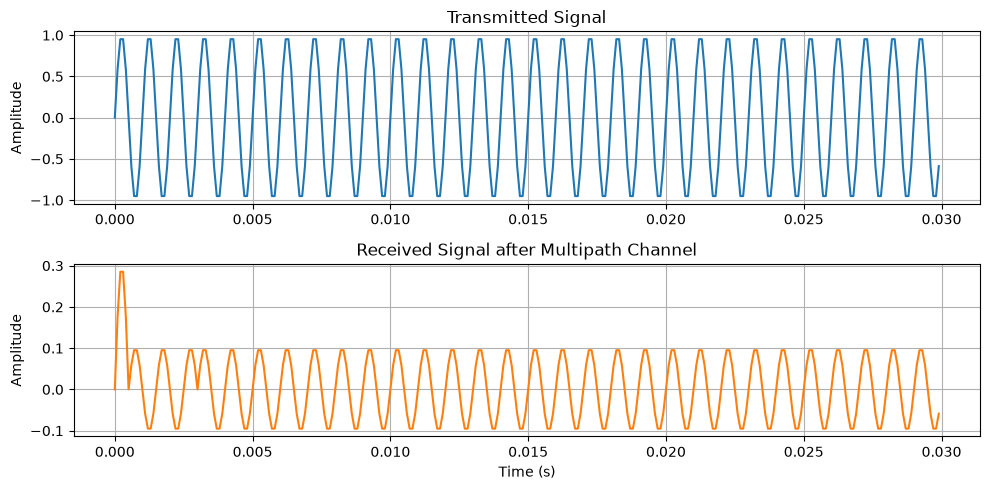

In [34]:
# convolve transmitted signal with channel impulse response
rx_multipath = np.convolve(tx, cir, mode='same')
# np.convolve(): applies the channel to the signal
# convolution = for each sample, sum all delayed and scaled copies
# mode='same': output same length as input — trims edges

# compute delay spread
delay_spread = (np.max(path_delays) - np.min(path_delays)) / fs * 1000
print(f"Delay spread: {delay_spread:.2f} ms")
# delay spread: time between first and last path arrival
# larger delay spread = more intersymbol interference (ISI)
# this is why OFDM uses cyclic prefix longer than delay spread

plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(t[:300], tx[:300], label="Transmitted", linewidth=1.5)
plt.title("Transmitted Signal")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t[:300], rx_multipath[:300], label="Received (multipath)", 
         color='C1', linewidth=1.5)
plt.title("Received Signal after Multipath Channel")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

Velocity: 60 km/h = 16.67 m/s
Carrier frequency: 2.4 GHz
Doppler shift: 133.33 Hz


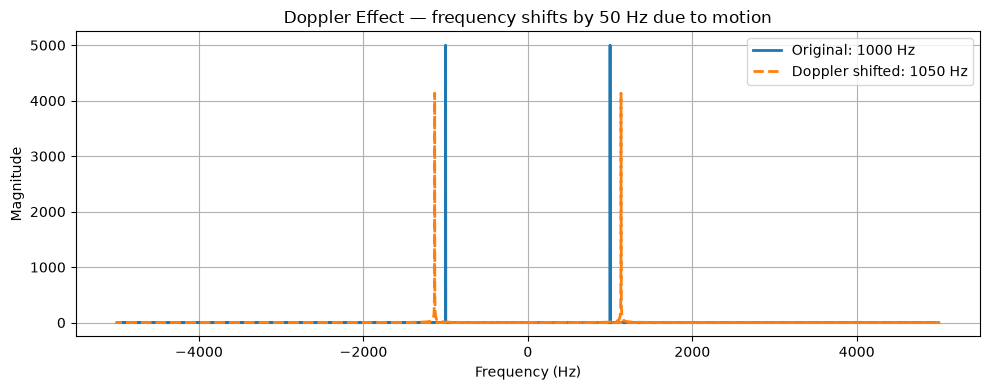

In [35]:
# --- Doppler shift: frequency changes due to relative motion ---
# if transmitter or receiver is moving, the received frequency shifts
# moving toward each other: frequency increases
# moving away: frequency decreases

v_kph = 60          # relative velocity in km/h — like a car moving
v_mps = v_kph / 3.6  # convert to m/s
# / 3.6: conversion factor from km/h to m/s

c = 3e8                # speed of light in m/s

f_real_carrier = 2.4e9 # real carrier frequency in Hz (2.4 GHz WiFi)

f_doppler = (v_mps / c) * f_real_carrier
# Doppler shift formula: fd = (v/c) * fc
# v: velocity in m/s
# c: speed of light
# fc: carrier frequency
# result: how many Hz the frequency shifts due to motion

print(f"Velocity: {v_kph} km/h = {v_mps:.2f} m/s")
print(f"Carrier frequency: {f_real_carrier/1e9:.1f} GHz")
print(f"Doppler shift: {f_doppler:.2f} Hz")
# at 60 km/h and 2.4 GHz, Doppler shift is about 133 Hz


# simulate Doppler effect on our test signal
# scale Doppler to our simulation frequency
f_doppler_sim = 50   # simulated Doppler shift in Hz

tx_doppler = np.sin(2 * np.pi * (f_carrier + f_doppler) * t)
# shifted signal: carrier + Doppler offset
# receiver expects f_carrier but gets f_carrier + f_doppler_sim

# show the frequency shift in FFT
N = len(t)
freqs = np.fft.fftfreq(N, 1/fs)

fft_tx = np.abs(np.fft.fft(tx))
fft_doppler = np.abs(np.fft.fft(tx_doppler))

plt.figure(figsize=(10, 4))
plt.plot(freqs, fft_tx,      label=f"Original: {f_carrier} Hz",              linewidth=2)
plt.plot(freqs, fft_doppler, label=f"Doppler shifted: {f_carrier + f_doppler_sim} Hz",
         linewidth=2, linestyle='--')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title(f"Doppler Effect — frequency shifts by {f_doppler_sim} Hz due to motion")
# plt.xlim(900, 1150)
# plt.xlim(): zoom in around carrier frequency to see the shift clearly
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


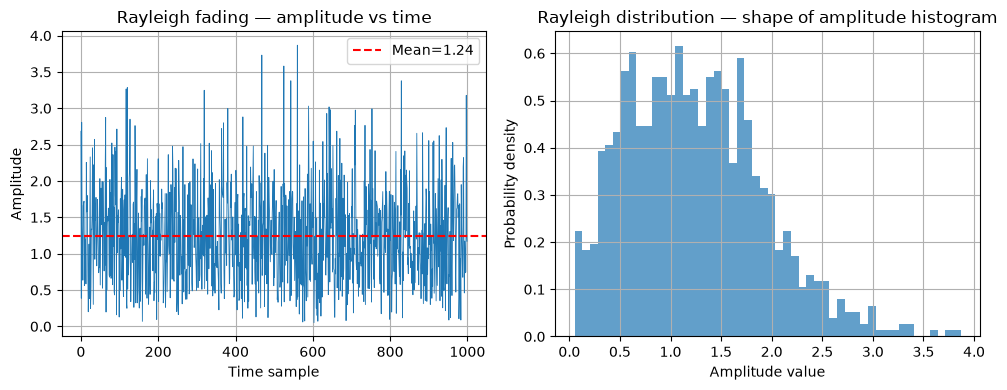

Mean amplitude: 1.2414
Min amplitude:  0.0516  ← deep fades
Max amplitude:  3.8680  ← strong moments


In [36]:
import numpy as np
import matplotlib.pyplot as plt

# imagine 1000 different moments in time
N = 1000

# at each moment, many reflections contribute randomly to I and Q
I = np.random.randn(N)   # random in-phase component
Q = np.random.randn(N)   # random quadrature component
# each value represents the SUM of many random reflections at that moment

amplitude = np.sqrt(I**2 + Q**2)
# received amplitude = magnitude of (I + jQ)
# this is what your receiver actually measures

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(amplitude, linewidth=0.6)
plt.xlabel("Time sample")
plt.ylabel("Amplitude")
plt.title("Rayleigh fading — amplitude vs time")
plt.axhline(y=np.mean(amplitude), color='r', 
            linestyle='--', label=f"Mean={np.mean(amplitude):.2f}")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.hist(amplitude, bins=50, density=True, color='C0', alpha=0.7)
# plt.hist(): plots histogram of amplitude values
# bins=50: divide range into 50 bars
# density=True: normalise so area under histogram = 1
plt.xlabel("Amplitude value")
plt.ylabel("Probability density")
plt.title("Rayleigh distribution — shape of amplitude histogram")
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Mean amplitude: {np.mean(amplitude):.4f}")
print(f"Min amplitude:  {np.min(amplitude):.4f}  ← deep fades")
print(f"Max amplitude:  {np.max(amplitude):.4f}  ← strong moments")

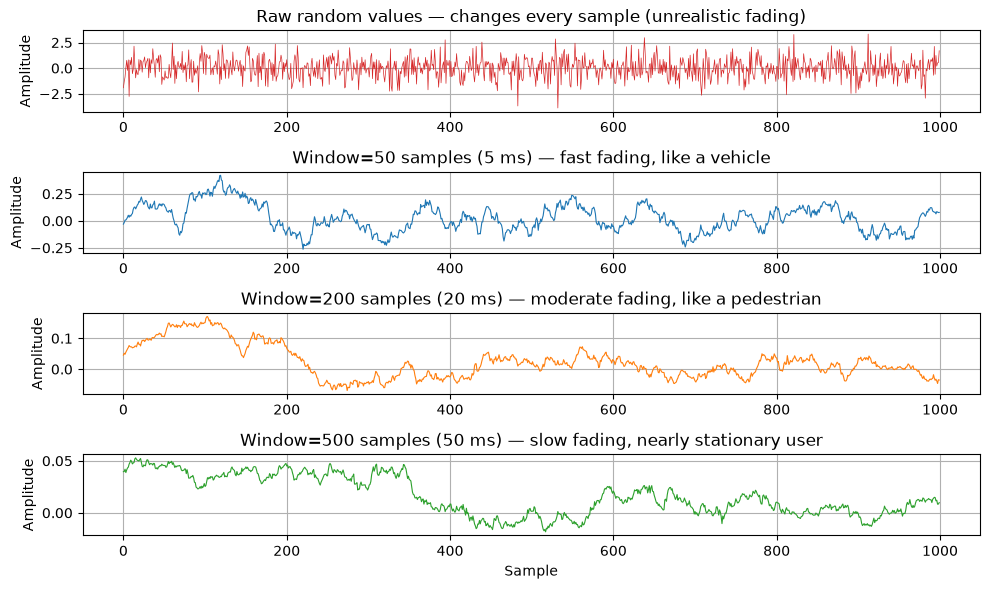

In [37]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000

# raw random fading — changes every single sample
I_raw = np.random.randn(N)
# np.random.randn(N): independent Gaussian value at every sample
# completely uncorrelated — unrealistically fast fading

# moving average window
window_50  = np.ones(50)  / 50
window_200 = np.ones(200) / 200
window_500 = np.ones(500) / 500
# np.ones(n): creates array of n ones
# / n: normalises so all values sum to 1
# this ensures the average is correctly scaled

# convolve = apply moving average
I_smooth_50  = np.convolve(I_raw, window_50,  mode='same')
I_smooth_200 = np.convolve(I_raw, window_200, mode='same')
I_smooth_500 = np.convolve(I_raw, window_500, mode='same')
# np.convolve(signal, window, mode):
# signal: the array to smooth
# window: the averaging kernel
# mode='same': output same length as input
#   (mode='full' would make output longer — we don't want that)
#   (mode='valid' would make output shorter — we don't want that either)

plt.figure(figsize=(10, 6))

plt.subplot(4, 1, 1)
plt.plot(I_raw, linewidth=0.5, color='C3')
plt.title("Raw random values — changes every sample (unrealistic fading)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(I_smooth_50, linewidth=0.8, color='C0')
plt.title("Window=50 samples (5 ms) — fast fading, like a vehicle")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(I_smooth_200, linewidth=0.8, color='C1')
plt.title("Window=200 samples (20 ms) — moderate fading, like a pedestrian")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(I_smooth_500, linewidth=0.8, color='C2')
plt.title("Window=500 samples (50 ms) — slow fading, nearly stationary user")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

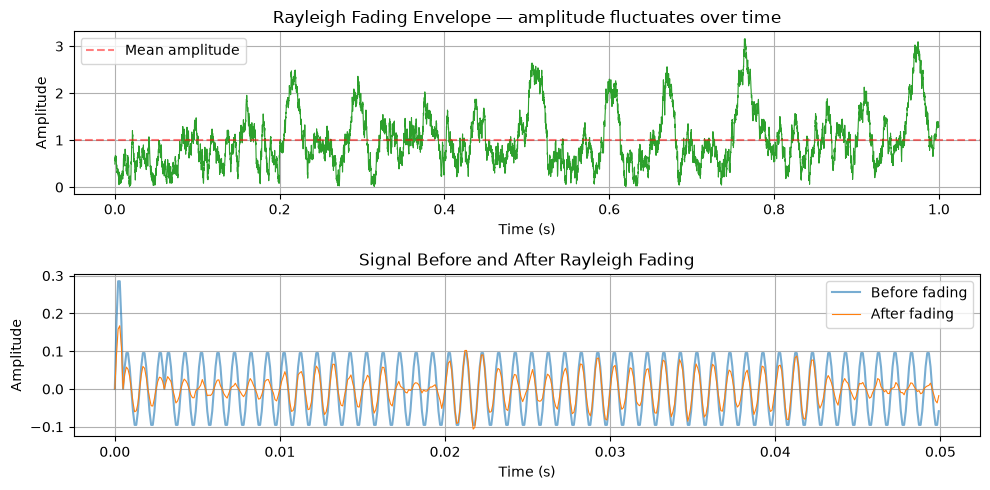

In [38]:
# --- Rayleigh fading: amplitude fluctuates randomly over time ---
# caused by many reflected paths adding constructively and destructively
# at different times — like ripples interfering on water

# generate Rayleigh fading envelope
# Rayleigh fading = magnitude of two independent Gaussian random variables
I = np.random.randn(len(t))
# I: in-phase component — Gaussian random values
# np.random.randn(): generates standard normal (Gaussian) random numbers
              
Q = np.random.randn(len(t))
# Q: quadrature component — independent Gaussian random values

# smooth them to simulate correlation over time (channel coherence)
window = np.ones(200) / 200
# np.ones(200)/200: moving average filter of length 200
# dividing by 200 normalises so sum = 1

I_smooth = np.convolve(I, window, mode='same')
Q_smooth = np.convolve(Q, window, mode='same')
# np.convolve(): smooths the random values
# without smoothing fading would change sample by sample — too fast

fading_envelope = np.sqrt(I_smooth**2 + Q_smooth**2)
# magnitude of complex fading = sqrt(I² + Q²)
# this is the Rayleigh distribution — models real wireless channels

fading_envelope = fading_envelope / np.mean(fading_envelope)
# normalise so average amplitude = 1
# makes it easy to see the fading effect

# apply fading to the multipath signal
rx_faded = rx_multipath * fading_envelope
# element-wise multiply: each sample scaled by fading amplitude at that time

plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(t, fading_envelope, color='C2', linewidth=0.8)
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Mean amplitude')
# plt.axhline(): horizontal reference line at amplitude = 1
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Rayleigh Fading Envelope — amplitude fluctuates over time")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t[:500], rx_multipath[:500], label="Before fading", alpha=0.6)
plt.plot(t[:500], rx_faded[:500],     label="After fading",  linewidth=0.8)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Signal Before and After Rayleigh Fading")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# --- combine all channel effects ---
# this is what a real wireless channel looks like

noise_amplitude = 0.1
noise = np.random.randn(len(t)) * noise_amplitude
# Gaussian noise added on top of everything

rx_full = rx_faded + noise
# full received signal: multipath + fading + noise

# compute SNR of the received signal
signal_power = np.mean(tx ** 2)
# mean squared amplitude of clean transmit signal

noise_power = np.mean(noise ** 2)
# mean squared amplitude of noise

snr_db = 10 * np.log10(signal_power / noise_power)
# 10 * np.log10(): convert power ratio to dB

print(f"Transmit signal power:  {signal_power:.4f}")
print(f"Noise power:            {noise_power:.4f}")
print(f"SNR:                    {snr_db:.2f} dB")

plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(t[:500], tx[:500], linewidth=1)
plt.title("1 — Transmitted signal (clean)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t[:500], rx_faded[:500], linewidth=0.8, color='C1')
plt.title("2 — After multipath + fading")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t[:500], rx_full[:500], linewidth=0.6, color='C2')
plt.title("3 — Final received signal (multipath + fading + noise)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

## What I learned
- Multipath: convolution of signal with channel impulse response
- Delay spread determines minimum cyclic prefix length in OFDM
- Rayleigh fading modelled as magnitude of two Gaussian random variables
- Doppler shift = (v/c) * fc — proportional to velocity and carrier frequency
- Real channel = multipath + fading + Doppler + noise combined

## More Information

Received multipath signal looks like noise — it's not noise, it's your clean sine wave plus delayed copies of itself interfering. When delayed copies add destructively at certain moments the amplitude drops, when they add constructively it rises. The result looks chaotic in time domain but the FFT would still show a spike at your carrier frequency — the frequency content is preserved, only the amplitude envelope is distorted. This distortion is called intersymbol interference (ISI) in digital systems and it's why OFDM was invented.

Rayleigh fading is a random line — exactly right. The amplitude dips and peaks randomly over time. Those deep dips are called deep fades — moments where the signal nearly disappears. In a real system this causes burst errors. Techniques like diversity combining (multiple antennas receiving simultaneously) are used so that when one antenna is in a deep fade, another is not. This is the fundamental motivation behind MIMO.

Doppler shifts carrier frequency — correct. Moving toward the transmitter shifts frequency up, moving away shifts it down. At 5G mmWave frequencies (28 GHz), even walking speed creates hundreds of Hz of Doppler shift — enough to completely throw off a receiver that isn't compensating for it. This is why 5G modems do continuous Doppler estimation and correction.

SNR = 17 dB — good. At 17 dB your signal is about 50x stronger than noise in linear scale (10^(17/10) = 50). That's a comfortable margin — most systems need at least 10 dB to decode reliably. With 64-QAM modulation (used in 5G) you'd typically need around 25 dB. So 17 dB would support QPSK but not higher order modulations.

Equal path amplitudes cause more distortion — when all paths have equal strength, the destructive interference is maximum. A delayed copy of amplitude 1.0 can completely cancel the direct path of amplitude 1.0 at certain frequencies — creating deep nulls in the frequency response. With unequal amplitudes [1.0, 0.7, 0.4, 0.2] the weaker reflections can never fully cancel the strong direct path. In real channel design this is why engineers prefer environments with a strong line-of-sight path — it dominates and prevents complete cancellation. This is quantified by the Rician K-factor — ratio of direct path power to scattered path power. Higher K = less severe fading.

Doppler shift 666 Hz at 300 km/h — exactly 5x the 133 Hz you got at 60 km/h, which makes sense since Doppler scales linearly with velocity fd = (v/c) * fc. At 300 km/h on a 2.4 GHz carrier, 666 Hz shift is significant — it moves your signal almost out of its intended subcarrier in an OFDM system. This is a real problem for high speed rail 5G — special Doppler compensation algorithms run continuously in the modem to track and correct this shift.

SNR dropped to 3 dB — at 3 dB your signal power is only 2x your noise power in linear scale. That's a very marginal link — most modulation schemes struggle below 10 dB. BPSK can just about work at 3 dB but you'd have significant bit errors. This is the regime where channel coding (LDPC, Turbo codes) becomes essential — adding redundancy so errors can be corrected even at low SNR.